## Quiz
* 다음 데이터셋(loan-train.csv)을 분석하여 loan-test.csv(새롭게 저장된 파일이면 새로운 파일에 넣으시오)데이터의 레이블을 구하시오
>
* Dream Housing Finance 회사는 모든 주택 융자를 취급합니다. 그들은 모든 도시, 중 도시 및 농촌 지역에 존재합니다.
* 해당 회사가 고객의 대출 자격을 확인한 후 주택 대출을 고객에게 해준다.
* 고객은 지원 양식을 작성하는 동안 회사는 고객 세부 정보를 기반으로 대출 자격 프로세스(실시간)를  자동화하려고 합니다. 
* 이러한 세부 정보는 성별, 결혼 여부, 교육, 부양 가족 수, 소득, 대출 금액, 신용 기록 등입니다. 
* 특정 고객이 각각의 값을 입력 했을 경우 대출이 되는지 안되는지 자동화를 진행하고자 한다.
>
* 컬럼
    - Loan_ID : 고유 대출 id
    - Gender : 성별(1:남성, 0:여성)
    - married : 1:기혼, 0:미혼
    - dependents : 부양가족 수
    - education : 대학원( 0:졸업, 1:미졸업 )
    - self_employed : 0:자영업 아님, 1:자영업
    - applicantlncome : 신청자 소득
    - coapplicantlncome : 신청인 소득
    - loanAmount : 대출금액(천만원)
    - loan_amount_term : 대출기간(개월)
    - credit_history : 신용 기록 지침(0:미충족, 1:충족)
    - property_area : 2:도시, 1:중 도시, 0:농촌
    - loan_status : 대출(1:승인, 0:거절)

### Quiz-4
1. 결측치를 해결하시오
    * 결측치 치환
        - Gender : Male 또는 Female
        - Married : Yes 또는 No
        - Dependents : 최빈값, ‘3+’는 3으로 변경
        - Self_Employed : 이전값
        - LoanAmount : 이후값
        - Loan_Amount_Term : 평균값
        - Credit_History : 1.0 또는 0.0
2. 문자열 데이터 처리
    * 참고
        - 타입 확인 : df.dtypes
        - 문자열 숫자 변환 : df['컬럼'] = pd.to_numeric(df['컬럼'])
3. 이상치를 해결하시오
    * 최빈값으로 치환 하세요 (이상치가 없다고 판단되면 변경 안해도 된다.)
4. 중복데이터를 해결하시오
* -------- 모델평가는 같이 진행 합니다 -----
5. 모델 평가
6. 최적의 모델을 이용하여 test.csv파일에 결과값(Loan_Status(대출): 승인, 거절)을 넣으시오.

In [149]:
#데이터 불러오기(loan-train.csv)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#### 결측치 확인

In [150]:
# 행, 열의 개수 및 결측치 확인


(614, 13)


Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

#### 1.결측치 치환
* Gender : Male 또는 Female
* Married : Yes 또는 No
* Dependents : 최빈값과 '3+'는 3으로 변경
* Self_Employed : 이전값
* LoanAmount : 이후값
* Loan_Amount_Term : 평균값
* Credit_History : 1.0 또는 0.0

In [151]:
# Gender 치환 전 값 확인 후 값 치환후 확인


['Male' 'Female' nan]


array(['Female', 'Male'], dtype=object)

In [152]:
#Married 치환 전 값 확인 후 값 치환후 확인


['No' 'Yes' nan]


array(['No', 'Yes'], dtype=object)

In [153]:
#Dependents 치환 전 값 확인 후 값 치환후 확인


['0' '1' '2' '3+' nan]
['0' '1' '2' '3+']


array(['0', '1', '2', '3'], dtype=object)

In [154]:
#Self_Employed 치환 전 값 확인 후 값 치환후 확인


['No' 'Yes' nan]


array(['No', 'Yes'], dtype=object)

In [155]:
#LoanAmount 치환 전 값 확인 후 값 치환후 확인


[ nan 128.  66. 120. 141. 267.  95. 158. 168. 349.  70. 109. 200. 114.
  17. 125. 100.  76. 133. 115. 104. 315. 116. 112. 151. 191. 122. 110.
  35. 201.  74. 106. 320. 144. 184.  80.  47.  75. 134.  96.  88.  44.
 286.  97. 135. 180.  99. 165. 258. 126. 312. 136. 172.  81. 187. 113.
 176. 130. 111. 167. 265.  50. 210. 175. 131. 188.  25. 137. 160. 225.
 216.  94. 139. 152. 118. 185. 154.  85. 259. 194.  93. 370. 182. 650.
 102. 290.  84. 242. 129.  30. 244. 600. 255.  98. 275. 121.  63. 700.
  87. 101. 495.  67.  73. 260. 108.  58.  48. 164. 170.  83.  90. 166.
 124.  55.  59. 127. 214. 240.  72.  60. 138.  42. 280. 140. 155. 123.
 279. 192. 304. 330. 150. 207. 436.  78.  54.  89. 143. 105. 132. 480.
  56. 159. 300. 376. 117.  71. 490. 173.  46. 228. 308. 236. 570. 380.
 296. 156. 103.  45.  65.  53. 360.  62. 218. 178. 239. 405. 148. 190.
 149. 153. 162. 230.  86. 234. 246. 500. 186. 119. 107. 209. 208. 243.
  40. 250. 311. 400. 161. 196. 324. 157. 145. 181.  26. 211.   9. 205.
  36. 

array([128.,  66., 120., 141., 267.,  95., 158., 168., 349.,  70., 109.,
       200., 114.,  17., 125., 100.,  76., 133., 115., 104., 315., 116.,
       112., 151., 191., 122., 110.,  35., 201.,  74., 106., 320., 144.,
       184.,  80.,  47.,  75., 134.,  96.,  88.,  44., 286.,  97., 135.,
       180.,  99., 165., 258., 126., 312., 136., 172.,  81., 187., 113.,
       176., 130., 111., 167., 265.,  50., 210., 175., 131., 188.,  25.,
       137., 160., 225., 216.,  94., 139., 152., 118., 185., 154.,  85.,
       259., 194.,  93., 370., 182., 650., 102., 290.,  84., 242., 129.,
        30., 244., 600., 255.,  98., 275., 121.,  63., 700.,  87., 101.,
       495.,  67.,  73., 260., 108.,  58.,  48., 164., 170.,  83.,  90.,
       166., 124.,  55.,  59., 127., 214., 240.,  72.,  60., 138.,  42.,
       280., 140., 155., 123., 279., 192., 304., 330., 150., 207., 436.,
        78.,  54.,  89., 143., 105., 132., 480.,  56., 159., 300., 376.,
       117.,  71., 490., 173.,  46., 228., 308., 23

In [156]:
#Loan_Amount_Term 치환 전 값 확인 후 값 치환후 확인


[360. 120. 240.  nan 180.  60. 300. 480.  36.  84.  12.]


array([360., 120., 240., 342., 180.,  60., 300., 480.,  36.,  84.,  12.])

In [157]:
#Credit_History 치환 전 값 확인 후 값 치환후 확인


[ 1.  0. nan]


array([1., 0.])

In [158]:
# 최종 결과 확인


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

* 결측값 처리 함수화

In [159]:
#데이터 불러오기(loan-train.csv)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


In [160]:
#모든 컬럼 확인


Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [161]:
#모든 결측 값 확인(반복문 이용)


Loan_ID  =>  ['LP001002' 'LP001003' 'LP001005' 'LP001006' 'LP001008' 'LP001011'
 'LP001013' 'LP001014' 'LP001018' 'LP001020' 'LP001024' 'LP001027'
 'LP001028' 'LP001029' 'LP001030' 'LP001032' 'LP001034' 'LP001036'
 'LP001038' 'LP001041' 'LP001043' 'LP001046' 'LP001047' 'LP001050'
 'LP001052' 'LP001066' 'LP001068' 'LP001073' 'LP001086' 'LP001087'
 'LP001091' 'LP001095' 'LP001097' 'LP001098' 'LP001100' 'LP001106'
 'LP001109' 'LP001112' 'LP001114' 'LP001116' 'LP001119' 'LP001120'
 'LP001123' 'LP001131' 'LP001136' 'LP001137' 'LP001138' 'LP001144'
 'LP001146' 'LP001151' 'LP001155' 'LP001157' 'LP001164' 'LP001179'
 'LP001186' 'LP001194' 'LP001195' 'LP001197' 'LP001198' 'LP001199'
 'LP001205' 'LP001206' 'LP001207' 'LP001213' 'LP001222' 'LP001225'
 'LP001228' 'LP001233' 'LP001238' 'LP001241' 'LP001243' 'LP001245'
 'LP001248' 'LP001250' 'LP001253' 'LP001255' 'LP001256' 'LP001259'
 'LP001263' 'LP001264' 'LP001265' 'LP001266' 'LP001267' 'LP001273'
 'LP001275' 'LP001279' 'LP001280' 'LP001282' 'LP0

In [162]:
#결측치 변경하는 함수를 만들어 결측치 치환



In [163]:
# 최종 결과 확인


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [164]:
# 아래 문자열 치환과 비교하기 위해 출력
df_train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#### 2.문자열 데이터 처리

In [165]:
#각 컬럼이 가지고 있는 값들의 자료형 확인


Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [166]:
#위에서 출력된 자료형과 비교


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y


In [167]:
#위의 결과에서 숫자형 문자인 컬럼의 유일한 값 출력


array(['0', '1', '2', '3'], dtype=object)

In [168]:
#문자열 숫자를 가지고 있는 값을 숫자로 변경 후 확인


array([0, 1, 2, 3], dtype=int64)

In [169]:
#성별(Gender)은 Male : 0, Female : 1로 변경하여 새로운 컬럼 Gender_int 에 저장 후 확인


,Gender,Gender_int
0,Male,0
1,Male,0
2,Male,0
3,Male,0
4,Male,0
...,...,...
609,Female,1
610,Male,0
611,Male,0
612,Male,0


In [170]:
#특정 컬럼의 값이 문자열인지 확인
print(type(df_train['Gender'][0]) == str)

True


In [171]:
# 나머지 문자열들은 자기 자신의 컬럼 위치에 숫자로 변환(LabelEncoder사용)


In [172]:
#숫자로 변환 결과 type 확인


Loan_ID                int32
Gender                 int32
Married                int32
Dependents             int64
Education              int32
Self_Employed          int32
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int32
Loan_Status            int32
Gender_int             int64
dtype: object

#### 3. 이상치를 해결하시오
* 최빈값으로 해결 하세요
* 이상치가 없다고 판단되면 변경 안해도 된다.

In [173]:
#통계값 확인


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Gender_int
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,306.500000,0.817590,0.653094,0.744300,0.218241,0.140065,5403.459283,1621.245798,146.416938,342.000000,0.855049,1.037459,0.687296,0.182410
std,177.390811,0.386497,0.476373,1.009623,0.413389,0.347338,6109.041673,2926.248369,84.917398,64.372489,0.352339,0.787482,0.463973,0.386497
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,153.250000,1.000000,0.000000,0.000000,0.000000,0.000000,2877.500000,0.000000,100.000000,360.000000,1.000000,0.000000,0.000000,0.000000
50%,306.500000,1.000000,1.000000,0.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000,0.000000
75%,459.750000,1.000000,1.000000,1.000000,0.000000,0.000000,5795.000000,2297.250000,166.750000,360.000000,1.000000,2.000000,1.000000,0.000000
max,613.000000,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000,1.000000


In [180]:
#1사분위와 3사분위의 값을 각각 구해 딕셔너리에 저장 후 출력


{'Gender': 1.0, 'Married': 0.0, 'Dependents': 0.0, 'Education': 0.0, 'Self_Employed': 0.0, 'ApplicantIncome': 2877.5, 'CoapplicantIncome': 0.0, 'LoanAmount': 100.0, 'Loan_Amount_Term': 360.0, 'Credit_History': 1.0, 'Property_Area': 0.0, 'Loan_Status': 0.0, 'Gender_int': 0.0}
{'Gender': 1.0, 'Married': 1.0, 'Dependents': 1.0, 'Education': 0.0, 'Self_Employed': 0.0, 'ApplicantIncome': 5795.0, 'CoapplicantIncome': 2297.25, 'LoanAmount': 166.75, 'Loan_Amount_Term': 360.0, 'Credit_History': 1.0, 'Property_Area': 2.0, 'Loan_Status': 1.0, 'Gender_int': 0.0}


,1사분위,3사분위
Gender,1.0,1.00
Married,0.0,1.00
Dependents,0.0,1.00
Education,0.0,0.00
Self_Employed,0.0,0.00
ApplicantIncome,2877.5,5795.00
CoapplicantIncome,0.0,2297.25
LoanAmount,100.0,166.75
Loan_Amount_Term,360.0,360.00
Credit_History,1.0,1.00


Gender


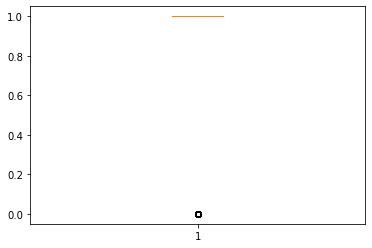

Married


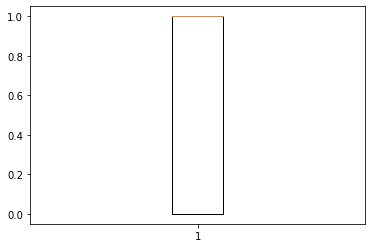

Dependents


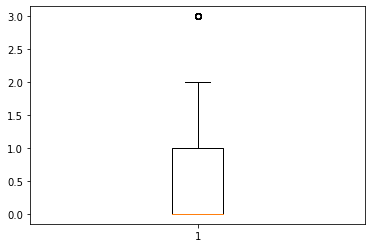

Education


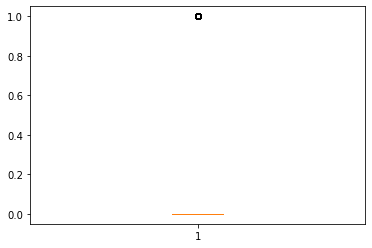

Self_Employed


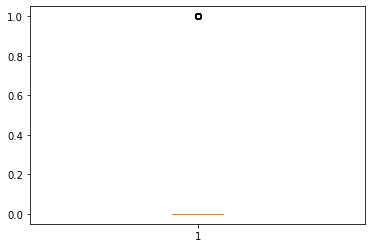

ApplicantIncome


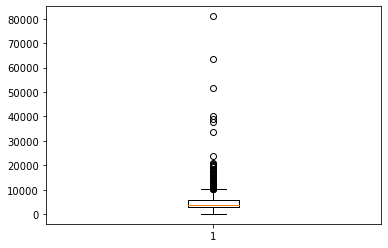

CoapplicantIncome


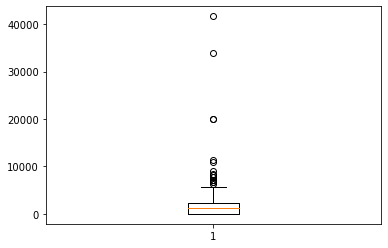

LoanAmount


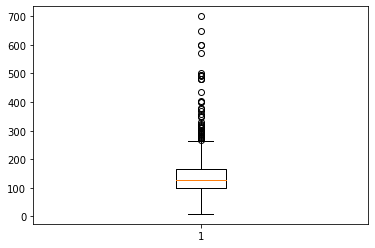

Loan_Amount_Term


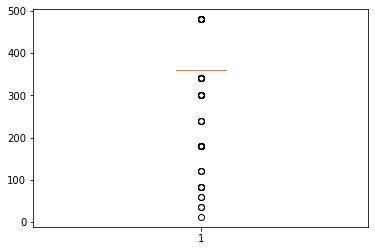

Credit_History


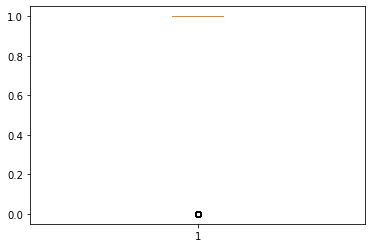

Property_Area


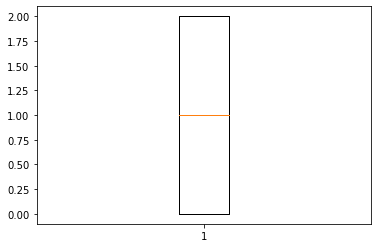

Loan_Status


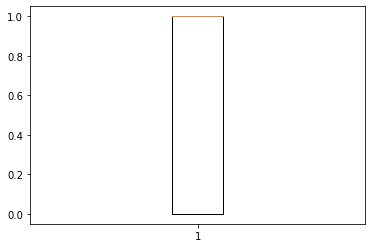

Gender_int


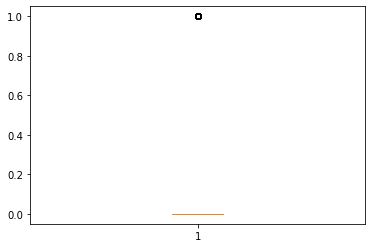

In [182]:
#아이디를 제외한 값들의 boxplot 확인


#### 4. 중복데이터를 해결하시오

In [176]:
# 중복데이터 확인


0

#### cleaning 데이터 저장

In [177]:
#df_train.to_csv('data/loan_train_cleaning.csv', index=False)